# Cursos de Machine Learning en el Sector Bancario
## Modulo 5. `Segmentación de Clientes`
                        Elaborado por: Naren Castellon

## `Segmentación de clientes bancarios`

La segmentación de clientes bancarios consiste en dividir a los clientes en grupos homogéneos según sus características y comportamientos. El algoritmo **K-means** se usa para identificar estos grupos de manera automática. Es importante porque permite personalizar productos, mejorar la fidelización y optimizar estrategias de marketing. Tiene ventajas como simplicidad y escalabilidad, pero también desventajas como sensibilidad a datos atípicos y necesidad de definir el número de segmentos previamente.

## `¿Qué es la segmentación de clientes bancarios?`
- Es el **proceso de clasificar clientes en grupos** con características similares (edad, ingresos, hábitos de consumo, uso de productos financieros).  
- Permite a los bancos **entender mejor a sus clientes** y diseñar estrategias específicas para cada segmento.  
- Ejemplo: un banco puede identificar clientes jóvenes que usan apps móviles, clientes de alto patrimonio que requieren asesoría personalizada, o clientes que buscan créditos accesibles.

## `Importancia de la segmentación bancaria`
- **Personalización de productos:** ofrecer tarjetas, créditos o seguros adaptados a cada perfil.  
- **Optimización de campañas:** dirigir promociones a los clientes más propensos a responder.  
- **Gestión de riesgos:** identificar clientes con mayor probabilidad de incumplimiento.  
- **Fidelización:** mejorar la experiencia del cliente y aumentar la retención.

## `¿Cómo funciona K-means en la segmentación?`
- **K-means clustering** es un algoritmo de aprendizaje no supervisado que agrupa datos en “clusters” (segmentos).  
- Funcionamiento básico:  
  1. Se elige un número \(k\) de grupos.  
  2. El algoritmo asigna cada cliente al grupo cuyo **centroide** (punto medio del cluster) esté más cercano.  
  3. Recalcula los centroides hasta que los grupos se estabilizan.  
- En banca, se aplican variables como ingresos, edad, frecuencia de transacciones, uso de productos financieros, etc..


## `Ventajas y desventajas de K-means en segmentación bancaria`

| **Ventajas** | **Desventajas** |
|--------------|-----------------|
| Fácil de implementar y entender | Requiere definir el número de clusters \(k\) previamente |
| Escalable a grandes volúmenes de datos | Sensible a valores atípicos y ruido |
| Convergencia rápida y eficiente | Puede generar clusters poco representativos si los datos no están bien normalizados |
| Permite descubrir patrones ocultos en clientes | No maneja bien clusters de diferentes tamaños o densidades |

## `Conclusión`
La segmentación de clientes bancarios con K-means es una herramienta poderosa para **entender mejor a los clientes y tomar decisiones estratégicas**. Sin embargo, requiere un buen preprocesamiento de datos y una correcta elección del número de segmentos para evitar resultados poco útiles.

### `Información del Dataset`

Dataset sintético desde cero para segmentación de clientes bancarios

Variables clave para clustering por comportamiento:

- customer_id: ID único (entero)
- age: Edad (18-80 años)
- gender: Género ('Male', 'Female', 'Other')
- annual_income: Ingreso anual (USD, 20k-200k)
- account_balance: Saldo en cuenta (0-500k)
- num_transactions: Transacciones mensuales (0-100)
- avg_transaction_amount: Monto promedio por transacción (50-5000 USD)
- credit_score: Puntaje crediticio (300-850)
- num_loans: Número de préstamos activos (0-5)
- num_cards: Número de tarjetas (0-5)
- has_savings_account: Cuenta de ahorros (0/1)
- has_investment: Inversiones (0/1)
- loyalty_score: Puntaje de lealtad (basado en antigüedad, 0-100)
- region: Región geográfica ('North', 'South', 'East', 'West') - Para segmentación demográfica
- preferred_channel: Canal preferido ('App', 'Branch', 'Online', 'ATM')

In [2]:
# Manipulacion y tratamiento de Datos
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Visualizacion de los Datos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelacion
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Evaluacion de los metodos
from sklearn.metrics import silhouette_score

# Ignorar algunas mensaje o advertencias
import warnings
warnings.filterwarnings('ignore')

In [3]:
bank_df = pd.read_csv('./bank_customers_segmentation.csv')
bank_df

,customer_id,age,gender,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score,region,preferred_channel
0,1,47,Male,32680,8299,31,52.368044,653,2,3,1,1,79,South,Branch
1,2,37,Female,53874,41314,25,197.657464,644,0,2,0,0,73,East,Branch
2,3,49,Male,86930,43567,28,50.000000,674,1,4,1,0,80,West,Branch
3,4,62,Female,34228,24224,23,50.000000,760,4,3,1,0,85,South,App
4,5,36,Male,29399,19760,30,228.744232,706,3,2,0,0,74,South,App
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,36,Male,49498,12698,35,104.493143,603,2,2,1,0,75,West,App
99996,99997,31,Female,20000,16531,26,110.993335,666,2,1,0,0,70,West,ATM
99997,99998,46,Female,38711,20520,31,50.000000,656,1,4,1,0,79,South,App
99998,99999,36,Female,23268,22730,42,50.000000,680,2,3,1,0,76,North,ATM


In [4]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             100000 non-null  int64  
 1   age                     100000 non-null  int64  
 2   gender                  100000 non-null  object 
 3   annual_income           100000 non-null  int64  
 4   account_balance         100000 non-null  int64  
 5   num_transactions        100000 non-null  int64  
 6   avg_transaction_amount  100000 non-null  float64
 7   credit_score            100000 non-null  int64  
 8   num_loans               100000 non-null  int64  
 9   num_cards               100000 non-null  int64  
 10  has_savings_account     100000 non-null  int64  
 11  has_investment          100000 non-null  int64  
 12  loyalty_score           100000 non-null  int64  
 13  region                  100000 non-null  object 
 14  preferred_channel    

In [5]:
bank_df.describe()

,customer_id,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,40.009880,41554.262100,22871.889410,30.667550,86.640519,683.770890,1.368410,2.709350,0.397320,0.201890,75.692630
std,28867.657797,13.992178,21254.567301,16928.971045,7.238184,57.064432,50.406035,1.176791,1.486767,0.489346,0.401413,6.164305
min,1.000000,18.000000,20000.000000,2001.000000,5.000000,50.000000,461.000000,0.000000,0.000000,0.000000,0.000000,62.000000
25%,25000.750000,29.000000,25896.000000,11005.000000,26.000000,50.000000,650.000000,0.000000,2.000000,0.000000,0.000000,71.000000
50%,50000.500000,40.000000,36269.000000,18658.500000,30.000000,50.000000,684.000000,1.000000,3.000000,0.000000,0.000000,76.000000
75%,75000.250000,50.000000,50832.000000,29948.250000,35.000000,110.154278,718.000000,2.000000,4.000000,1.000000,0.000000,80.000000
max,100000.000000,80.000000,200000.000000,193116.000000,63.000000,503.998389,850.000000,5.000000,5.000000,1.000000,1.000000,96.000000


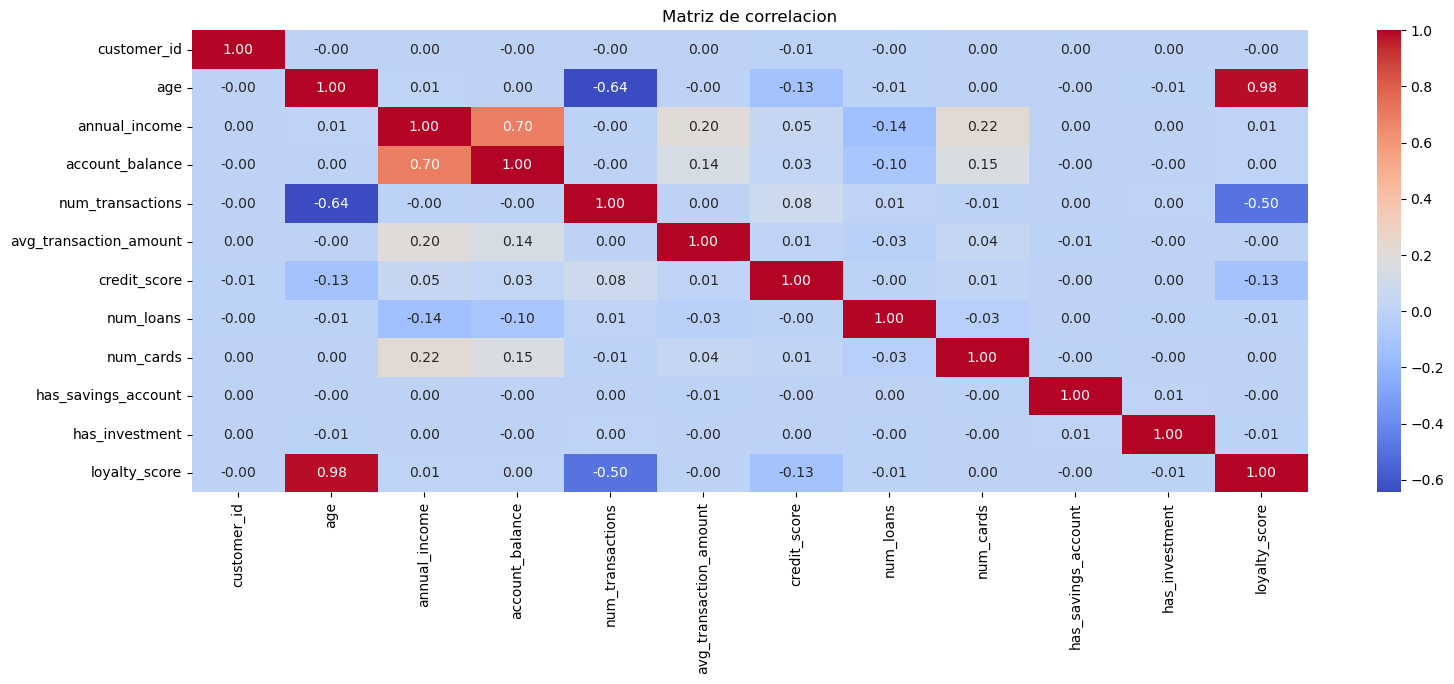

In [6]:
# Correlacion de los datos

numeric_cols = bank_df.select_dtypes(include= [np.number]).columns
corr_matrix = bank_df[numeric_cols].corr()
plt.figure(figsize=(18,6))
sns.heatmap(corr_matrix, annot= True, cmap= 'coolwarm', fmt = '.2f')
plt.title('Matriz de correlacion')
plt.show()

In [7]:
bank_df.columns

Index(['customer_id', 'age', 'gender', 'annual_income', 'account_balance',
       'num_transactions', 'avg_transaction_amount', 'credit_score',
       'num_loans', 'num_cards', 'has_savings_account', 'has_investment',
       'loyalty_score', 'region', 'preferred_channel'],
      dtype='object')

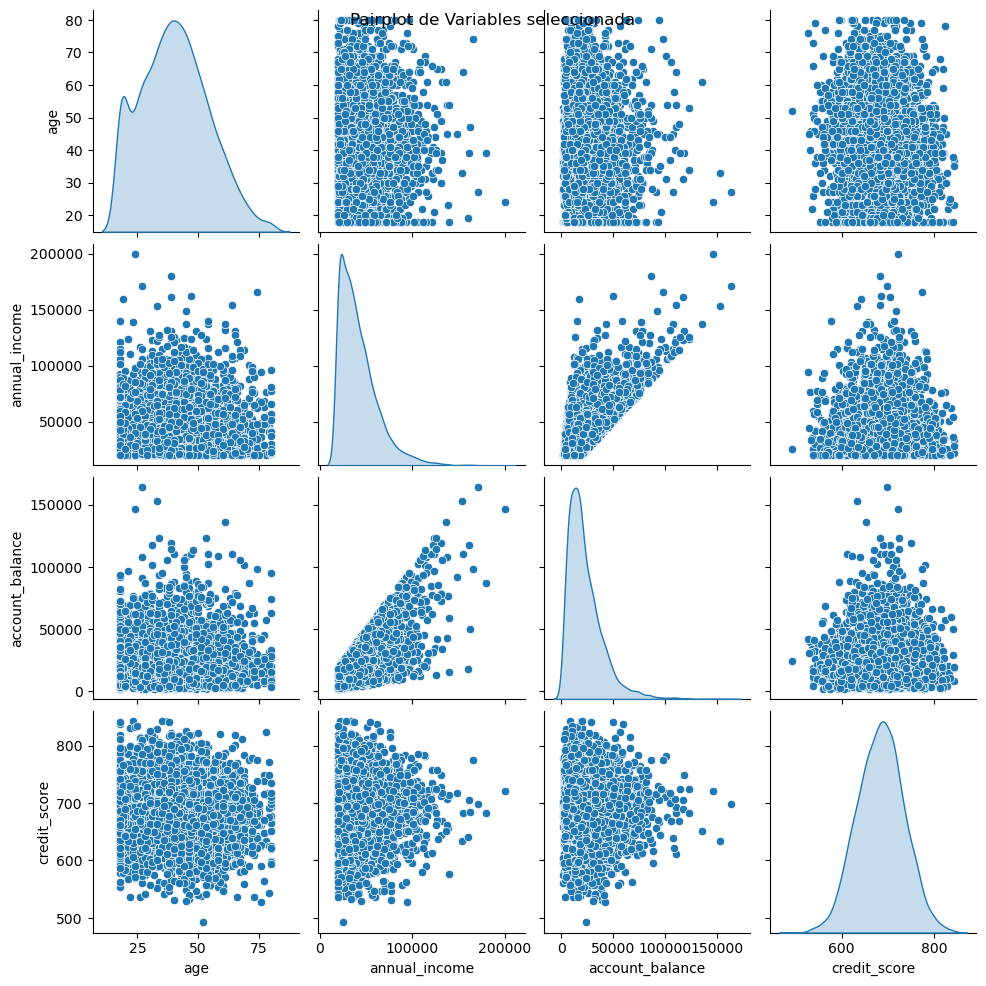

In [9]:
#pairplot 

sns.pairplot(bank_df.sample(5000)[["age", 'annual_income', 'account_balance', 'credit_score',]], diag_kind= 'kde')
plt.suptitle('Pairplot de Variables seleccionada')
plt.show()

In [10]:
bank_df

,customer_id,age,gender,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score,region,preferred_channel
0,1,47,Male,32680,8299,31,52.368044,653,2,3,1,1,79,South,Branch
1,2,37,Female,53874,41314,25,197.657464,644,0,2,0,0,73,East,Branch
2,3,49,Male,86930,43567,28,50.000000,674,1,4,1,0,80,West,Branch
3,4,62,Female,34228,24224,23,50.000000,760,4,3,1,0,85,South,App
4,5,36,Male,29399,19760,30,228.744232,706,3,2,0,0,74,South,App
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,36,Male,49498,12698,35,104.493143,603,2,2,1,0,75,West,App
99996,99997,31,Female,20000,16531,26,110.993335,666,2,1,0,0,70,West,ATM
99997,99998,46,Female,38711,20520,31,50.000000,656,1,4,1,0,79,South,App
99998,99999,36,Female,23268,22730,42,50.000000,680,2,3,1,0,76,North,ATM


In [11]:
# Codificar con One_hot_Encoding

cat_cols = ['gender', 'region', 'preferred_channel']
bank_df = pd.get_dummies(bank_df, columns= cat_cols, drop_first= True)


In [12]:
bank_df

,customer_id,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score,gender_Male,gender_Other,region_North,region_South,region_West,preferred_channel_App,preferred_channel_Branch,preferred_channel_Online
0,1,47,32680,8299,31,52.368044,653,2,3,1,1,79,True,False,False,True,False,False,True,False
1,2,37,53874,41314,25,197.657464,644,0,2,0,0,73,False,False,False,False,False,False,True,False
2,3,49,86930,43567,28,50.000000,674,1,4,1,0,80,True,False,False,False,True,False,True,False
3,4,62,34228,24224,23,50.000000,760,4,3,1,0,85,False,False,False,True,False,True,False,False
4,5,36,29399,19760,30,228.744232,706,3,2,0,0,74,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,36,49498,12698,35,104.493143,603,2,2,1,0,75,True,False,False,False,True,True,False,False
99996,99997,31,20000,16531,26,110.993335,666,2,1,0,0,70,False,False,False,False,True,False,False,False
99997,99998,46,38711,20520,31,50.000000,656,1,4,1,0,79,False,False,False,True,False,True,False,False
99998,99999,36,23268,22730,42,50.000000,680,2,3,1,0,76,False,False,True,False,False,False,False,False


In [13]:
bank_df.columns

Index(['customer_id', 'age', 'annual_income', 'account_balance',
       'num_transactions', 'avg_transaction_amount', 'credit_score',
       'num_loans', 'num_cards', 'has_savings_account', 'has_investment',
       'loyalty_score', 'gender_Male', 'gender_Other', 'region_North',
       'region_South', 'region_West', 'preferred_channel_App',
       'preferred_channel_Branch', 'preferred_channel_Online'],
      dtype='object')

In [22]:
num_cols = ['age', 'annual_income', 'account_balance', 'num_transactions', 'avg_transaction_amount', 
            'credit_score', 'num_loans', 'num_cards', 'has_savings_account', 'has_investment', 'loyalty_score']

In [23]:
scaler = StandardScaler()
bank_df[num_cols] = scaler.fit_transform(bank_df[num_cols])

In [24]:
bank_df

,customer_id,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score,gender_Male,gender_Other,region_North,region_South,region_West,preferred_channel_App,preferred_channel_Branch,preferred_channel_Online
0,1,0.499576,-0.417525,-0.860830,0.045930,-0.600596,-0.610463,0.536708,0.195492,1.231610,1.988264,0.536538,True,False,False,True,False,False,True,False
1,2,-0.215113,0.579631,1.089387,-0.783011,1.945476,-0.789014,-1.162837,-0.477112,-0.811945,-0.502951,-0.436812,False,False,False,False,False,False,True,False
2,3,0.642514,2.134881,1.222473,-0.368540,-0.642094,-0.193845,-0.313065,0.868096,1.231610,-0.502951,0.698764,True,False,False,False,True,False,True,False
3,4,1.571609,-0.344693,0.079870,-1.059325,-0.642094,1.512309,2.236253,0.195492,1.231610,-0.502951,1.509889,False,False,False,True,False,True,False,False
4,5,-0.286582,-0.571892,-0.183821,-0.092227,2.490245,0.441003,1.386480,-0.477112,-0.811945,-0.502951,-0.274587,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,-0.286582,0.373744,-0.600978,0.598558,0.312852,-1.602413,0.536708,-0.477112,1.231610,-0.502951,-0.112362,True,False,False,False,True,True,False,False
99996,99997,-0.643926,-1.014105,-0.374560,-0.644854,0.426762,-0.352557,0.536708,-1.149716,-0.811945,-0.502951,-0.923488,False,False,False,False,True,False,False,False
99997,99998,0.428107,-0.133772,-0.138928,0.045930,-0.642094,-0.550947,-0.313065,0.868096,1.231610,-0.502951,0.536538,False,False,False,True,False,True,False,False
99998,99999,-0.286582,-0.860349,-0.008381,1.565656,-0.642094,-0.074811,0.536708,0.195492,1.231610,-0.502951,0.049863,False,False,True,False,False,False,False,False


In [25]:
# seleccionar variables

X = bank_df.drop(columns= ['customer_id'])
X

,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score,gender_Male,gender_Other,region_North,region_South,region_West,preferred_channel_App,preferred_channel_Branch,preferred_channel_Online
0,0.499576,-0.417525,-0.860830,0.045930,-0.600596,-0.610463,0.536708,0.195492,1.231610,1.988264,0.536538,True,False,False,True,False,False,True,False
1,-0.215113,0.579631,1.089387,-0.783011,1.945476,-0.789014,-1.162837,-0.477112,-0.811945,-0.502951,-0.436812,False,False,False,False,False,False,True,False
2,0.642514,2.134881,1.222473,-0.368540,-0.642094,-0.193845,-0.313065,0.868096,1.231610,-0.502951,0.698764,True,False,False,False,True,False,True,False
3,1.571609,-0.344693,0.079870,-1.059325,-0.642094,1.512309,2.236253,0.195492,1.231610,-0.502951,1.509889,False,False,False,True,False,True,False,False
4,-0.286582,-0.571892,-0.183821,-0.092227,2.490245,0.441003,1.386480,-0.477112,-0.811945,-0.502951,-0.274587,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.286582,0.373744,-0.600978,0.598558,0.312852,-1.602413,0.536708,-0.477112,1.231610,-0.502951,-0.112362,True,False,False,False,True,True,False,False
99996,-0.643926,-1.014105,-0.374560,-0.644854,0.426762,-0.352557,0.536708,-1.149716,-0.811945,-0.502951,-0.923488,False,False,False,False,True,False,False,False
99997,0.428107,-0.133772,-0.138928,0.045930,-0.642094,-0.550947,-0.313065,0.868096,1.231610,-0.502951,0.536538,False,False,False,True,False,True,False,False
99998,-0.286582,-0.860349,-0.008381,1.565656,-0.642094,-0.074811,0.536708,0.195492,1.231610,-0.502951,0.049863,False,False,True,False,False,False,False,False


In [30]:
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []  # nombre distinto
k_range = range(2, 10)

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))


In [31]:
k_range = range(2, 10)

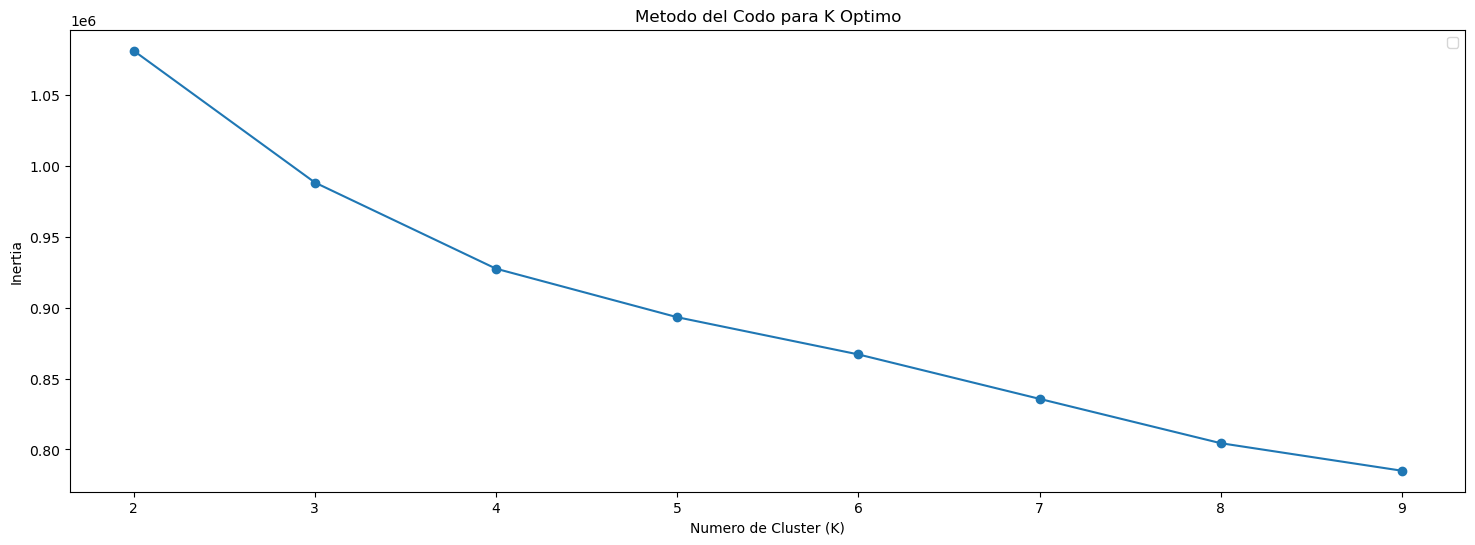

In [32]:
# Graficos Elbow
plt.figure(figsize=(18,6))
plt.plot(k_range, inertia, marker = 'o')
plt.title("Metodo del Codo para K Optimo")
plt.xlabel('Numero de Cluster (K)')
plt.ylabel('Inertia')
plt.legend()
plt.show()

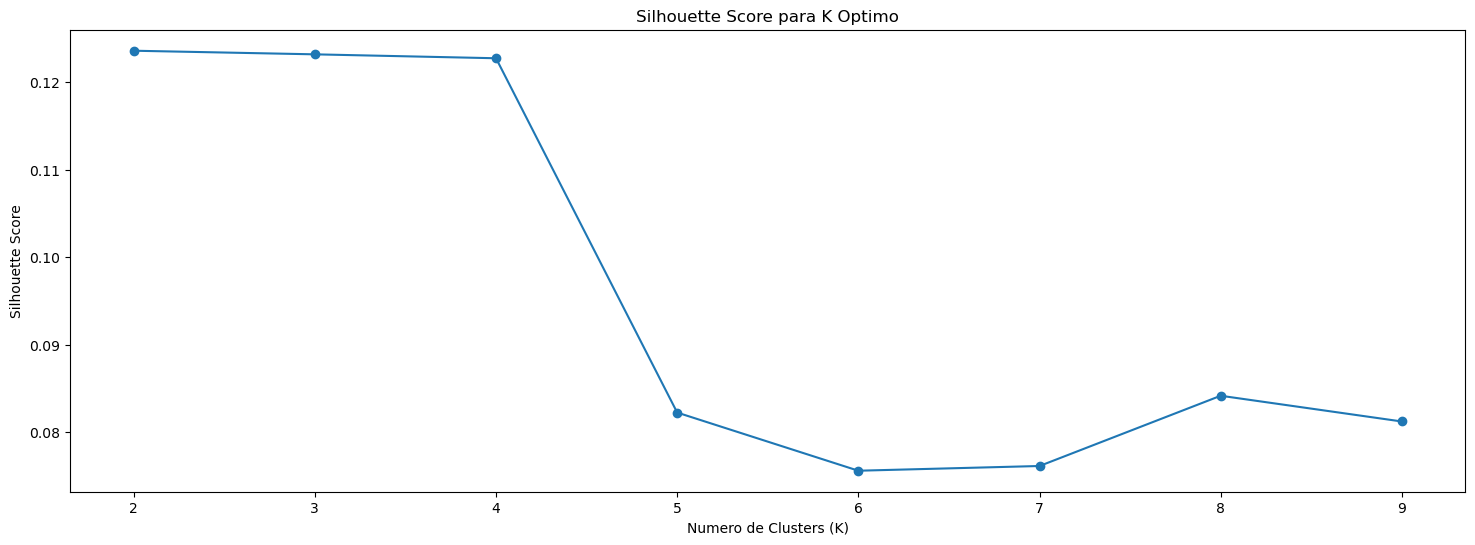

In [33]:
# Grafico silhoutte

plt.figure(figsize=(18,6))
plt.plot(k_range, sil_scores, marker = 'o')
plt.title('Silhouette Score para K Optimo')
plt.xlabel('Numero de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [34]:
# Seleccionar el valor optimo
optimal_k = 4

In [36]:
kmeans = KMeans(n_clusters= optimal_k, random_state= 42)
bank_df['cluster'] = kmeans.fit_predict(X)

In [37]:
bank_df

,customer_id,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,...,loyalty_score,gender_Male,gender_Other,region_North,region_South,region_West,preferred_channel_App,preferred_channel_Branch,preferred_channel_Online,cluster
0,1,0.499576,-0.417525,-0.860830,0.045930,-0.600596,-0.610463,0.536708,0.195492,1.231610,...,0.536538,True,False,False,True,False,False,True,False,3
1,2,-0.215113,0.579631,1.089387,-0.783011,1.945476,-0.789014,-1.162837,-0.477112,-0.811945,...,-0.436812,False,False,False,False,False,False,True,False,2
2,3,0.642514,2.134881,1.222473,-0.368540,-0.642094,-0.193845,-0.313065,0.868096,1.231610,...,0.698764,True,False,False,False,True,False,True,False,2
3,4,1.571609,-0.344693,0.079870,-1.059325,-0.642094,1.512309,2.236253,0.195492,1.231610,...,1.509889,False,False,False,True,False,True,False,False,0
4,5,-0.286582,-0.571892,-0.183821,-0.092227,2.490245,0.441003,1.386480,-0.477112,-0.811945,...,-0.274587,True,False,False,True,False,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,-0.286582,0.373744,-0.600978,0.598558,0.312852,-1.602413,0.536708,-0.477112,1.231610,...,-0.112362,True,False,False,False,True,True,False,False,1
99996,99997,-0.643926,-1.014105,-0.374560,-0.644854,0.426762,-0.352557,0.536708,-1.149716,-0.811945,...,-0.923488,False,False,False,False,True,False,False,False,1
99997,99998,0.428107,-0.133772,-0.138928,0.045930,-0.642094,-0.550947,-0.313065,0.868096,1.231610,...,0.536538,False,False,False,True,False,True,False,False,0
99998,99999,-0.286582,-0.860349,-0.008381,1.565656,-0.642094,-0.074811,0.536708,0.195492,1.231610,...,0.049863,False,False,True,False,False,False,False,False,1


In [38]:
bank_df['cluster'].value_counts()

cluster
1    38300
0    32368
3    16371
2    12961
Name: count, dtype: int64

In [39]:
# Visualizacion de Cluster con PCA
pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X)
bank_df["pca1"] = X_pca[:, 0]
bank_df["pca2"] = X_pca[:, 1]

In [40]:
bank_df

,customer_id,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,...,gender_Other,region_North,region_South,region_West,preferred_channel_App,preferred_channel_Branch,preferred_channel_Online,cluster,pca1,pca2
0,1,0.499576,-0.417525,-0.860830,0.045930,-0.600596,-0.610463,0.536708,0.195492,1.231610,...,False,False,True,False,False,True,False,3,0.667357,-1.051071
1,2,-0.215113,0.579631,1.089387,-0.783011,1.945476,-0.789014,-1.162837,-0.477112,-0.811945,...,False,False,False,False,False,True,False,2,0.107793,1.604690
2,3,0.642514,2.134881,1.222473,-0.368540,-0.642094,-0.193845,-0.313065,0.868096,1.231610,...,False,False,False,True,False,True,False,2,1.050567,2.270226
3,4,1.571609,-0.344693,0.079870,-1.059325,-0.642094,1.512309,2.236253,0.195492,1.231610,...,False,False,True,False,True,False,False,0,2.178545,-0.624771
4,5,-0.286582,-0.571892,-0.183821,-0.092227,2.490245,0.441003,1.386480,-0.477112,-0.811945,...,False,False,True,False,True,False,False,1,-0.369984,-0.203018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,-0.286582,0.373744,-0.600978,0.598558,0.312852,-1.602413,0.536708,-0.477112,1.231610,...,False,False,False,True,True,False,False,1,-0.323358,-0.394204
99996,99997,-0.643926,-1.014105,-0.374560,-0.644854,0.426762,-0.352557,0.536708,-1.149716,-0.811945,...,False,False,False,True,False,False,False,1,-0.604531,-1.230325
99997,99998,0.428107,-0.133772,-0.138928,0.045930,-0.642094,-0.550947,-0.313065,0.868096,1.231610,...,False,False,True,False,True,False,False,0,0.647331,-0.071939
99998,99999,-0.286582,-0.860349,-0.008381,1.565656,-0.642094,-0.074811,0.536708,0.195492,1.231610,...,False,True,False,False,False,False,False,1,-0.903635,-0.787939


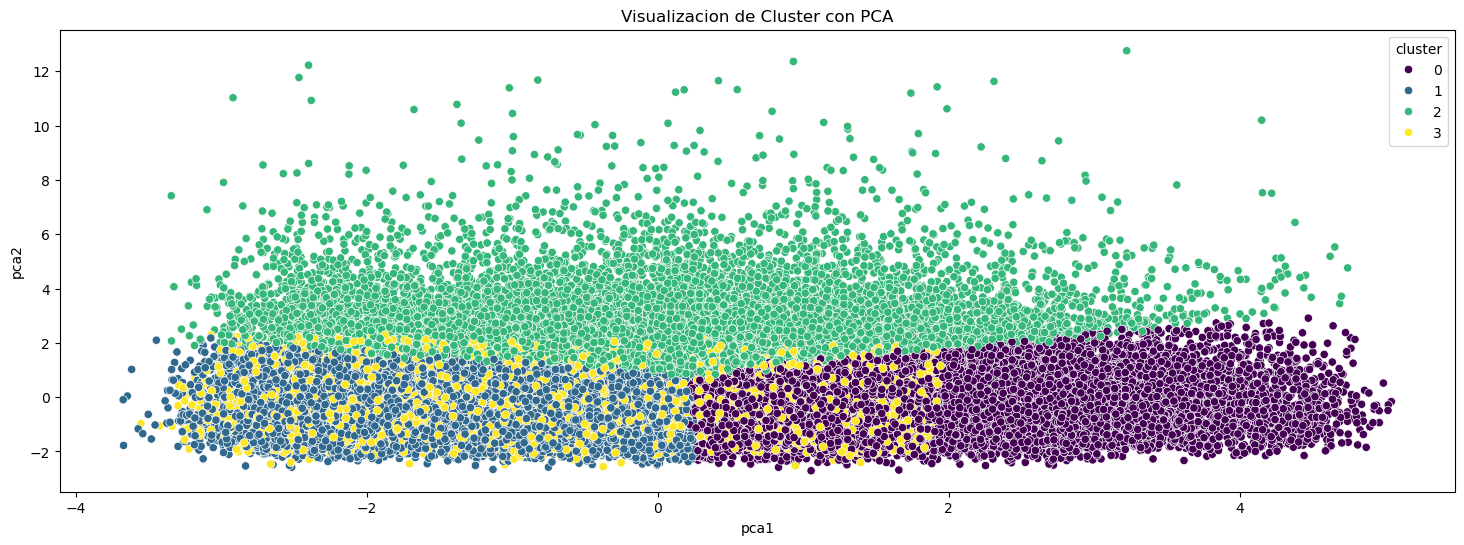

In [42]:
# Ver los cluster del PCA
plt.figure(figsize= (18, 6))
sns.scatterplot(x = 'pca1', y = 'pca2', hue = 'cluster', data =  bank_df, palette= 'viridis')
plt.title('Visualizacion de Cluster con PCA')
plt.show()

In [43]:
# Realizar un analis de Cluster

cluster_profiles = bank_df.groupby('cluster')[num_cols].mean().round(2)
cluster_profiles

,age,annual_income,account_balance,num_transactions,avg_transaction_amount,credit_score,num_loans,num_cards,has_savings_account,has_investment,loyalty_score
cluster,,,,,,,,,,,
0,1.00,-0.26,-0.25,-0.75,-0.09,-0.23,0.04,-0.08,-0.01,-0.34,0.96
1,-0.73,-0.30,-0.29,0.55,-0.10,0.13,0.07,-0.10,-0.00,-0.50,-0.70
2,-0.03,1.77,1.73,0.01,0.61,0.13,-0.37,0.55,0.01,-0.19,-0.03
3,-0.26,-0.19,-0.19,0.19,-0.06,0.04,0.03,-0.05,0.01,1.99,-0.25


In [44]:
# sugerencia de marketing basado en cluster

for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    st = f"\nCluster {cluster}:"
    if profile['annual_income']> 0.5:
        st += "Clientes de alto ingrenso. Ofrecer: Inversion Premium, Tarjeta elite."
    elif profile['age'] < -0.5: # persona joven
        st += "Clientes Jovenes. Ofrecer: Prestamos estudiantiles, app banking con rewards."
    elif profile['num_loans'] > 0.5:
        st += "Clientes con Deuda. Ofrecer: Refinanciamiento, asesoria financiera."
    else:
        st += "Clientes estandar. Ofrecer: Cuenta de Ahorro con bonos, promociones basicas" 
    print(st)



Cluster 0:Clientes estandar. Ofrecer: Cuenta de Ahorro con bonos, promociones basicas

Cluster 1:Clientes Jovenes. Ofrecer: Prestamos estudiantiles, app banking con rewards.

Cluster 2:Clientes de alto ingrenso. Ofrecer: Inversion Premium, Tarjeta elite.

Cluster 3:Clientes estandar. Ofrecer: Cuenta de Ahorro con bonos, promociones basicas
